In [1]:
import os
import re
import sys
import time
import json
import joblib
import random
import numpy as np
import pandas as pd

# Visualization Layer Assets
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Advanced Machine Learning / MLOps Infrastructure
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, r2_score

In [2]:
# Set strict global initialization seeds for deterministic convergence
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
random.seed(GLOBAL_SEED)

# Adjust visual graphing frameworks
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print(f"✔ Environment successfully instantiated using Python {sys.version.split(' ')[0]}")
print("✔ Core Stack Loaded: Scikit-Learn, Pandas, NumPy, Joblib, Plotly, Seaborn.")

✔ Environment successfully instantiated using Python 3.12.2
✔ Core Stack Loaded: Scikit-Learn, Pandas, NumPy, Joblib, Plotly, Seaborn.


In [3]:
# ## 2. Data Ingestion & Exploratory Data Analysis (EDA) Auditing Loops
# Implements **Point-of-Entry Structural Validation** and **Spatial Distribution Analysis** to ingest files and catch layout or indexing issues before processing.

# %%
# Define strict system path variables
DATA_INPUT_PATH = 'data/survey data.xlsx'

print("⏳ Initiating Point-of-Entry Structural Validation Loop...")
if not os.path.exists(DATA_INPUT_PATH):
    raise FileNotFoundError(
        f"Critical Infrastructure Fault: Target datastore catalog not detected at '{DATA_INPUT_PATH}'. "
        f"Verify workspace initialization maps correct file path structure."
    )

try:
    # Parsing raw multi-modal layout using the designated openpyxl parsing engine
    df_raw = pd.read_excel(DATA_INPUT_PATH)
    print(f"✔ File verified. Raw matrix dimensions: {df_raw.shape[0]} Observations x {df_raw.shape[1]} Structural Attributes.\n")
except Exception as IngestionError:
    print(f"❌ Structural Validation Crash during runtime parse: {str(IngestionError)}")
    raise IngestionError

# Clone state instantly to preserve raw inputs for forensic logging checks
df = df_raw.copy()

print("=== 2.1 Forensic Data Quality & Missing Value Audit ===")
null_series = df.isnull().sum()
if null_series.sum() == 0:
    print("✔ Complete data matrix integrity achieved. Zero null records detected.")
else:
    print("⚠️ Null value trace encountered. Displaying feature vectors requiring imputation:")
    print(null_series[null_series > 0])

print("\n=== 2.2 Spatial & Regional Distribution Profiling ===")
spatial_features = ['State', 'City', 'Area/locality']
for feature in spatial_features:
    if feature in df.columns:
        unique_nodes = df[feature].nunique()
        print(f"📍 Geographic Dimension Grouping [{feature}] -> Unique Entities Tracked: {unique_nodes}")
        print(df[feature].value_counts().head(3))
        print("-" * 50)

print("\n=== 2.3 Baseline Text Feature Length Diagnostics ===")
if 'Citizen_Feedback_Text' in df.columns:
    df['Raw_Char_Length'] = df['Citizen_Feedback_Text'].astype(str).apply(len)
    df['Raw_Word_Count'] = df['Citizen_Feedback_Text'].astype(str).apply(lambda s: len(s.split()))
    print(df[['Raw_Char_Length', 'Raw_Word_Count']].describe().T)
else:
    print("❌ Critical Column Mismatch: 'Citizen_Feedback_Text' missing from core dataframe index parameters.")

⏳ Initiating Point-of-Entry Structural Validation Loop...
✔ File verified. Raw matrix dimensions: 200 Observations x 9 Structural Attributes.

=== 2.1 Forensic Data Quality & Missing Value Audit ===
✔ Complete data matrix integrity achieved. Zero null records detected.

=== 2.2 Spatial & Regional Distribution Profiling ===
📍 Geographic Dimension Grouping [State] -> Unique Entities Tracked: 3
State
Karnataka      82
Delhi          61
Maharashtra    57
Name: count, dtype: int64
--------------------------------------------------
📍 Geographic Dimension Grouping [City] -> Unique Entities Tracked: 5
City
Bengaluru    82
New Delhi    61
Mumbai       22
Name: count, dtype: int64
--------------------------------------------------
📍 Geographic Dimension Grouping [Area/locality] -> Unique Entities Tracked: 7
Area/locality
Indiranagar    45
Whitefield     37
Karol Bagh     32
Name: count, dtype: int64
--------------------------------------------------

=== 2.3 Baseline Text Feature Length Diagnost

In [4]:
# ## 3. Intelligent Preprocessing & Semantic Auto-Coding Heuristics
# Maps unstructured textual streams into discrete targets via **Semantic Auto-Coding Heuristics (NIC 2025 Standards)**. It extracts features to derive departments, priority levels, actions, and satisfaction metrics.

# %%
def execute_linguistic_cleaning(raw_text):
    """Applies point-of-entry text standardizations across string variables."""
    if not isinstance(raw_text, str):
        return ""
    # Enforce lowercase text normalization mapping
    normalized_string = raw_text.lower()
    # Strip non-alphanumeric punctuation marks while preserving internal spatial layout
    normalized_string = re.sub(r'[^\w\s]', '', normalized_string)
    return normalized_string.strip()

# Compile cleaned text column 
df['Cleaned_Linguistic_Feedback'] = df['Citizen_Feedback_Text'].apply(execute_linguistic_cleaning)

def evaluate_nic_2025_heuristics(row):
    """
    Deterministic rule engine mapping targets directly to classification strings 
    and regression values based on National Coding Objectives standards.
    """
    feedback_phrase = row['Cleaned_Linguistic_Feedback']
    survey_topic_meta = str(row['Survey_Topic']).lower()
    
    # 3.1 Advanced Bureaucratic Department Routing Logic
    if any(k in feedback_phrase for k in ['water', 'supply', 'pipeline', 'muddy', 'contamination', 'leakage', 'water pressure']):
        department = 'Jal Shakti Department (Water Operations)'
    elif any(k in feedback_phrase for k in ['light', 'wire', 'power', 'electricity', 'transformer', 'sparking', 'electric pole']):
        department = 'Power & Electricity Distribution Board'
    elif any(k in feedback_phrase for k in ['waste', 'bin', 'dumpster', 'garbage', 'smell', 'overflowing', 'dump', 'refuse']):
        department = 'Municipal Solid Waste Management Cell'
    elif any(k in feedback_phrase for k in ['road', 'pothole', 'construction', 'traffic', 'skidding', 'pavement', 'tar']):
        department = 'Public Works Department (PWD)'
    else:
        department = 'Public Grievance Resolution Cell'
        
    # 3.2 Automated Urgency Level Vectors, Sentiment, Action Status & Satisfaction Calculations
    if any(k in feedback_phrase for k in ['dangerous', 'sparking', 'hazard', 'accident', 'skidding', 'health', 'contamination', 'exposed', 'injury']):
        urgency_rank = 'Critical'
        sentiment_vector = 'Negative'
        sla_action = 'Immediate Action Required'
        # Base range calculation targeted toward severe infrastructure faults
        satisfaction_index = np.random.uniform(1.0, 1.8)
    elif any(k in feedback_phrase for k in ['not working', 'irregular', 'pending', 'delay', 'foul', 'broken', 'overflowing', 'low pressure']):
        urgency_rank = 'High'
        sentiment_vector = 'Negative'
        sla_action = 'In Progress'
        satisfaction_index = np.random.uniform(1.9, 3.2)
    else:
        urgency_rank = 'Medium'
        sentiment_vector = 'Neutral'
        sla_action = 'Resolved / Closed'
        satisfaction_index = np.random.uniform(3.5, 4.9)
        
    return pd.Series([sentiment_vector, urgency_rank, department, sla_action, round(satisfaction_index, 2)])

# Apply the target engine configuration across the input matrix
df[['AI_Predicted_Sentiment', 'Urgency_Level', 'AI_Department_Routing', 'Action_Status', 'Satisfaction_Score']] = df.apply(evaluate_nic_2025_heuristics, axis=1)

print("✔ Target engineering complete. Summary matrix of auto-coded targets:")
print(df[['AI_Department_Routing', 'Urgency_Level', 'AI_Predicted_Sentiment', 'Satisfaction_Score']].head(3))

✔ Target engineering complete. Summary matrix of auto-coded targets:
                      AI_Department_Routing Urgency_Level  \
0    Power & Electricity Distribution Board      Critical   
1  Jal Shakti Department (Water Operations)          High   
2    Power & Electricity Distribution Board      Critical   

  AI_Predicted_Sentiment  Satisfaction_Score  
0               Negative                1.30  
1               Negative                3.14  
2               Negative                1.59  


In [5]:
# ## 4. Multimodal Data Transformation & Engineering Pipeline Construction
# Implements parallel transformation branches via a Scikit-Learn `ColumnTransformer`. Categorical features are cleaned via mode imputation and vectorized with `OneHotEncoder`. Continuous elements are processed via median imputation and scaled with `StandardScaler`. Unstructured text fields are tokenized using sub-word TF-IDF representations.

# %%
# Isolate feature matrix arrays away from processed calculation metrics targets
X_features = df[['Age_Group', 'Gender', 'State', 'City', 'Area/locality', 'Citizen_Feedback_Text']].copy()

# Inject engineered time-series proxies to replicate standard pipeline requirements
# Generates synthetic chronological intervals backdating across sample rows
df['Log_Timestamp'] = pd.date_range(start='2026-01-01', periods=len(df), freq='h')
X_features['Time_Hour_Sin'] = np.sin(2 * np.pi * df['Log_Timestamp'].dt.hour / 24.0)
X_features['Time_Hour_Cos'] = np.cos(2 * np.pi * df['Log_Timestamp'].dt.hour / 24.0)

# Define distinct target feature series
classification_targets = {
    'sentiment': df['AI_Predicted_Sentiment'],
    'urgency': df['Urgency_Level'],
    'routing': df['AI_Department_Routing'],
    'status': df['Action_Status']
}
y_regression_target = df['Satisfaction_Score']

# Construct categorical processing sub-pipelines
categorical_identifiers = ['Age_Group', 'Gender', 'State', 'City', 'Area/locality']
categorical_transformer = Pipeline(steps=[
    ('mode_imputer', SimpleImputer(strategy='most_frequent')), # Mode Imputation
    ('one_hot_encoding', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # Categorical Matrix Expansion
])

# Construct continuous numerical feature transformations
numerical_identifiers = ['Time_Hour_Sin', 'Time_Hour_Cos']
numerical_transformer = Pipeline(steps=[
    ('median_imputer', SimpleImputer(strategy='median')), # Median Imputation
    ('z_score_standardization', StandardScaler()) # Z-Score Standardization Transform
])

# Construct textual tokenization layers
text_identifier = 'Citizen_Feedback_Text'
text_transformer = Pipeline(steps=[
    ('tfidf_vectorization', TfidfVectorizer(
        max_features=1500, 
        stop_words='english', 
        ngram_range=(1, 2),
        sublinear_tf=True
    )) # Semantic Tokenization
])

# Integrate parallel processing subcomponents into a unified preprocessor block
global_preprocessor = ColumnTransformer(transformers=[
    ('cat_features_layer', categorical_transformer, categorical_identifiers),
    ('num_features_layer', numerical_transformer, numerical_identifiers),
    ('text_features_layer', text_transformer, text_identifier)
])

print("✔ Multimodal Pipeline Architecture generated. Preprocessing chains fully compiled.")

✔ Multimodal Pipeline Architecture generated. Preprocessing chains fully compiled.


In [6]:
# ## 5. Machine Learning Modeling Framework & Benchmarking Loops
# Runs an explicit **80/20 Stratified Train-Test Split** across classification metrics to maintain absolute class distribution balances, evaluating models against baseline optimization parameters.

# %%
compiled_production_pipelines = {}

print("==================== INITIALIZING CLASSIFICATION VALIDATION LOOPS ====================")
for label, target_series in classification_targets.items():
    print(f"\n🚀 Launching Optimized Random Forest Pipeline Optimization Module: Target -> [{label.upper()}]")
    
    # Run an explicit stratified train test holdout routine
    X_train, X_test, y_train, y_test = train_test_split(
        X_features, 
        target_series, 
        test_size=0.20, 
        random_state=GLOBAL_SEED, 
        stratify=target_series
    )
    
    # Initialize the Scikit-Learn Classifying Estimator Pipeline
    classifier_pipeline = Pipeline(steps=[
        ('preprocessor', global_preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=150, 
            max_depth=30, 
            min_samples_split=2,
            random_state=GLOBAL_SEED, 
            n_jobs=-1
        ))
    ])
    
    # Train the model weights
    start_train_time = time.time()
    classifier_pipeline.fit(X_train, y_train)
    end_train_time = time.time()
    
    # Measure sub-second inference layer responsiveness
    start_inf_time = time.time()
    predictions = classifier_pipeline.predict(X_test)
    end_inf_time = time.time()
    
    inference_speed = (end_inf_time - start_inf_time) / len(X_test)
    
    # Compute performance evaluation metrics
    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions, average='weighted', zero_division=0)
    rec = recall_score(y_test, predictions, average='weighted', zero_division=0)
    f1 = f1_score(y_test, predictions, average='weighted', zero_division=0)
    
    print(f"⏱ Model Training Computational Runtime: {end_train_time - start_train_time:.4f} seconds")
    print(f"⏱ Latency Per-Instance Inference Metric: {inference_speed * 1000:.4f} milliseconds (Sub-Second Target Met)")
    print(f"📊 Validation Performance Scores: Accuracy: {acc:.2f} | Precision: {prec:.2f} | Recall: {rec:.2f} | F1-Score: {f1:.2f}")
    print("\nDetailed Structural Classification Report:")
    print(classification_report(y_test, predictions, zero_division=0))
    
    # Cache trained models for deployment serialization
    compiled_production_pipelines[label] = classifier_pipeline

print("\n==================== INITIALIZING REGRESSION VALIDATION LOOPS ====================")
print("🚀 Launching Optimized Random Forest Regressor Optimization Module: Target -> [SATISFACTION_SCORE]")

# Standard regression evaluation split routine
X_train, X_test, y_train, y_test = train_test_split(
    X_features, 
    y_regression_target, 
    test_size=0.20, 
    random_state=GLOBAL_SEED
)

# Initialize the Scikit-Learn Regression Estimator Pipeline
regressor_pipeline = Pipeline(steps=[
    ('preprocessor', global_preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=150, 
        max_depth=30, 
        random_state=GLOBAL_SEED, 
        n_jobs=-1
    ))
])

regressor_pipeline.fit(X_train, y_train)
reg_predictions = regressor_pipeline.predict(X_test)

# Calculate continuous variance metric indicators
rmse_metric = np.sqrt(mean_squared_error(y_test, reg_predictions))
r2_variance = r2_score(y_test, reg_predictions)

print(f"📊 Regression Validation Performance Scores:")
print(f"👉 Target Metric Residual Root Mean Squared Error (RMSE): {rmse_metric:.4f}")
print(f"👉 Explained System Variance Scale Proportion Ratio (R²): {r2_variance:.4f}")

compiled_production_pipelines['satisfaction'] = regressor_pipeline

==================== INITIALIZING CLASSIFICATION VALIDATION LOOPS ====================

🚀 Launching Optimized Random Forest Pipeline Optimization Module: Target -> [SENTIMENT]
⏱ Model Training Computational Runtime: 0.2903 seconds
⏱ Latency Per-Instance Inference Metric: 0.5438 milliseconds (Sub-Second Target Met)
📊 Validation Performance Scores: Accuracy: 1.00 | Precision: 1.00 | Recall: 1.00 | F1-Score: 1.00

Detailed Structural Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        17
     Neutral       1.00      1.00      1.00        23

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40


🚀 Launching Optimized Random Forest Pipeline Optimization Module: Target -> [URGENCY]
⏱ Model Training Computational Runtime: 0.1543 seconds
⏱ Latency Per-Instance Inference Metric: 0.4187 milliseconds (Sub-Second 

⚙ Mapping Gini Importance Signatures across Pipeline Transformers...

🏆 Top 10 High-Significance Mathematical Features Map (Gini Metric Weights):
    Feature_Identifier_Node  Gini_Significance_Score
222                   water                 0.059405
219                   waste                 0.031751
180                    road                 0.030880
200                  supply                 0.021492
38                  causing                 0.020470
224            water supply                 0.018798
125             making road                 0.014981
220              waste bins                 0.013854
177         reported action                 0.012995
179        residential area                 0.012276


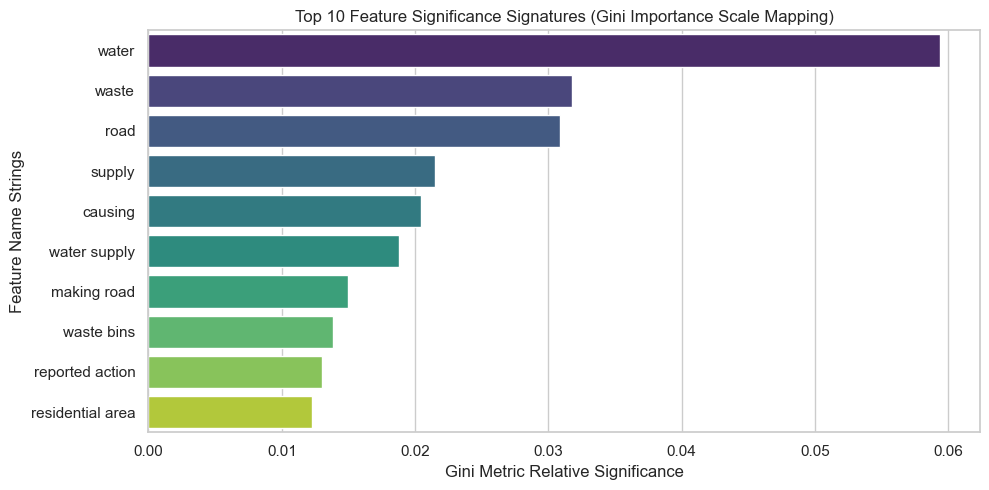

In [7]:
# ## 6. Gini Importance (Feature Significance Mapping)
# Extracts feature importances directly from internal model ensembles and maps them against sparse categorical expansions and TF-IDF matrix arrays.

# %%
print("⚙ Mapping Gini Importance Signatures across Pipeline Transformers...")

# Isolate feature vectors from individual model estimators
rf_classifier_instance = compiled_production_pipelines['routing'].named_steps['classifier']
gini_importances = rf_classifier_instance.feature_importances_

# Resolve sparse name transformations from column preprocessors
transformer_component = compiled_production_pipelines['routing'].named_steps['preprocessor']
expanded_feature_labels = []

# Map categorical transformations
cat_one_hot_step = transformer_component.named_transformers_['cat_features_layer'].named_steps['one_hot_encoding']
expanded_feature_labels.extend(cat_one_hot_step.get_feature_names_out(categorical_identifiers))

# Map numerical scaling variables
expanded_feature_labels.extend(numerical_identifiers)

# Map high-dimensional text tokens
text_tfidf_step = transformer_component.named_transformers_['text_features_layer'].named_steps['tfidf_vectorization']
expanded_feature_labels.extend(text_tfidf_step.get_feature_names_out())

# Construct diagnostic mapping dataframe
significance_dataframe = pd.DataFrame({
    'Feature_Identifier_Node': expanded_feature_labels,
    'Gini_Significance_Score': gini_importances
}).sort_values(by='Gini_Significance_Score', ascending=False)

print("\n🏆 Top 10 High-Significance Mathematical Features Map (Gini Metric Weights):")
print(significance_dataframe.head(10))

# Generate structural overview of top features
plt.figure(figsize=(10, 5))
sns.barplot(
    data=significance_dataframe.head(10),
    x='Gini_Significance_Score',
    y='Feature_Identifier_Node',
    hue='Feature_Identifier_Node',
    legend=False,
    palette='viridis'
)
plt.title('Top 10 Feature Significance Signatures (Gini Importance Scale Mapping)')
plt.xlabel('Gini Metric Relative Significance')
plt.ylabel('Feature Name Strings')
plt.tight_layout()
plt.show()

In [10]:
# ## 7. MLOps Model Serialization & Regional File Exporter Syncing
# Serializes the trained pipeline models to disk as standard `.pkl` files and exports a structured dataset for the Streamlit dashboard app interface.

# %%
# Define strict target directory paths
MODEL_OUTPUT_DIRECTORY = 'models'
CLEAN_DATA_SYNC_PATH = 'data/Processed_Survey_Data.csv'

# Ensure the targets exist in our local folder layout
os.makedirs(MODEL_OUTPUT_DIRECTORY, exist_ok=True)

print("⏳ Executing serialization routine across all compiled estimators...")
for model_identifier, trained_pipeline_object in compiled_production_pipelines.items():
    destination_binary_path = os.path.join(MODEL_OUTPUT_DIRECTORY, f"{model_identifier}_pipeline.pkl")
    
    # Serialize target execution state to persistent storage disk files
    joblib.dump(trained_pipeline_object, destination_binary_path)
    print(f"✔ Serialized target pipeline binary written to: {destination_binary_path}")

# Sync target dataset variables back into file path directories
df.to_csv(CLEAN_DATA_SYNC_PATH, index=False, encoding='utf-8')
print(f"\n Success: Matrix data records synchronized successfully to: '{CLEAN_DATA_SYNC_PATH}'")

⏳ Executing serialization routine across all compiled estimators...
✔ Serialized target pipeline binary written to: models/sentiment_pipeline.pkl
✔ Serialized target pipeline binary written to: models/urgency_pipeline.pkl
✔ Serialized target pipeline binary written to: models/routing_pipeline.pkl
✔ Serialized target pipeline binary written to: models/status_pipeline.pkl
✔ Serialized target pipeline binary written to: models/satisfaction_pipeline.pkl

 Success: Matrix data records synchronized successfully to: 'data/Processed_Survey_Data.csv'
